In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def sift_heatmap(image):
    
    return 

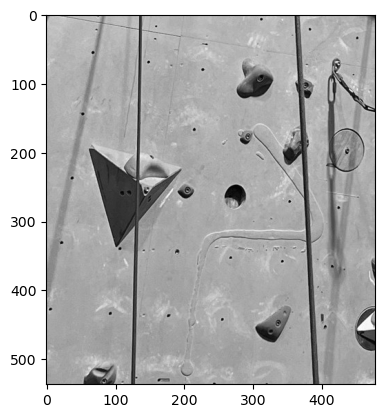

In [3]:
image = cv2.imread('crop.jpg')
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_image, cmap="gray")
plt.show()

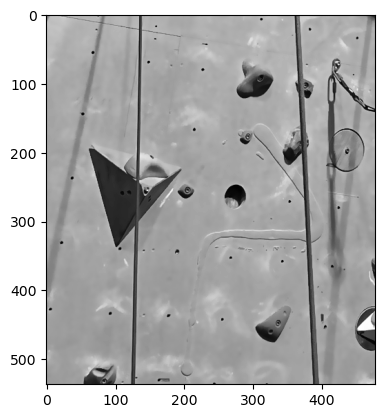

In [12]:
bilateral = cv2.bilateralFilter(image, 9, 50, 50)  
# converting to grayscale before bilateral filtering makes the computer colorblind,
# causing it to blur edges that should be distinct -> therefore filter is applied on rgb
bilateral_rgb = cv2.cvtColor(bilateral, cv2.COLOR_BGR2RGB) 
bil_gray_image = cv2.cvtColor(bilateral_rgb, cv2.COLOR_BGR2GRAY)

plt.imshow(bil_gray_image, cmap="gray")

In [13]:
image.shape

(537, 477, 3)

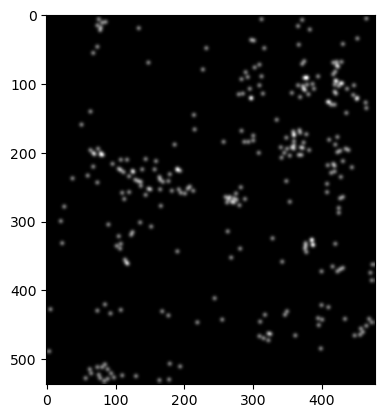

In [36]:
# better to pass grayscale image with applied bilateral filter:
# so rgb -> bilateral -> convert to grayscale -> input image
def sift_heatmap(img):
    h, w = image.shape[0], image.shape[1]
    
    sift_matrix = np.zeros(img.shape[:2])
    sift = cv2.SIFT_create()
    keypoints, _ = sift.detectAndCompute(img, None)

    for kp in keypoints:
        x, y = int(round(kp.pt[0])), int(round(kp.pt[1]))
        if 0 <= y < h and 0 <= x < w:
            sift_matrix[y, x] = 255

    sift_blur = cv2.GaussianBlur(sift_matrix, (15, 15), 0)
    
    return sift_blur

s = sift_heatmap(bil_gray_image)
plt.imshow(s, cmap="gray")

In [24]:
image.shape[:2]

(537, 477)

In [25]:
keypoints[0].pt

(4.24221134185791, 488.8882751464844)

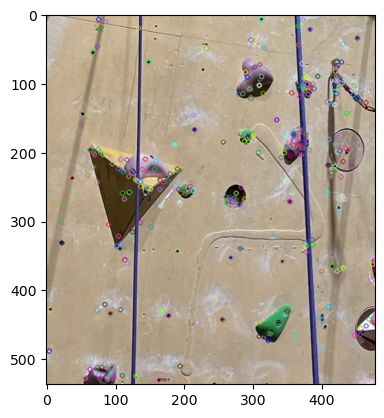

In [29]:
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(bil_gray_image, None)
image_with_sift = cv2.drawKeypoints(image, keypoints, None)

plt.imshow(cv2.cvtColor(image_with_sift, cv2.COLOR_BGR2RGB))